In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.quantum_info import Statevector

from itertools import product

In [2]:
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.facecolor": "#0b1020",
    "axes.facecolor": "#0b1020",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": "#e2e8f0",
    "xtick.color": "#cbd5e1",
    "ytick.color": "#cbd5e1",
    "text.color": "#e2e8f0",
    "axes.titleweight": "bold",
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 3.0,
    "grid.color": "#334155",
    "grid.alpha": 0.35,
    "axes.grid": True,
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})

In [3]:
import numpy as np

def bragg_hamiltonian(delta: float, omega: float) -> np.ndarray:
    return np.array(
        [
            [4 + delta, omega, 0],
            [omega, 0, omega],
            [0, omega, 4 - delta],
        ],
        dtype=float,
    )

In [4]:
H = bragg_hamiltonian(delta=0, omega=0.5)
print(np.allclose(H, H.conj().T))

True


In [5]:
eigenvalues, eigenvectors = np.linalg.eigh(H)
ground_energy = eigenvalues[0]
ground_state = eigenvectors[:, 0]

populations = np.abs(ground_state) ** 2
p_minus = populations[0]
p_zero = populations[1]
p_plus = populations[2]

print(f"Exact Ground Energy: ", ground_energy)
print(f"Exact Ground State: ", ground_state)

Exact Ground Energy:  -0.12132034355964301
Exact Ground State:  [-0.11957316  0.98559856 -0.11957316]


In [6]:
delta_values = np.linspace(-8, 8, 300)
omega_values = [0.1, 0.5, 1.0]

all_energies = []

for omega in omega_values:
    energies_for_this_omega = []
    for delta in delta_values:
        H = bragg_hamiltonian(delta, omega=omega)
        eigenvalues = np.linalg.eigvalsh(H)
        energies_for_this_omega.append(eigenvalues)
    all_energies.append(np.array(energies_for_this_omega))

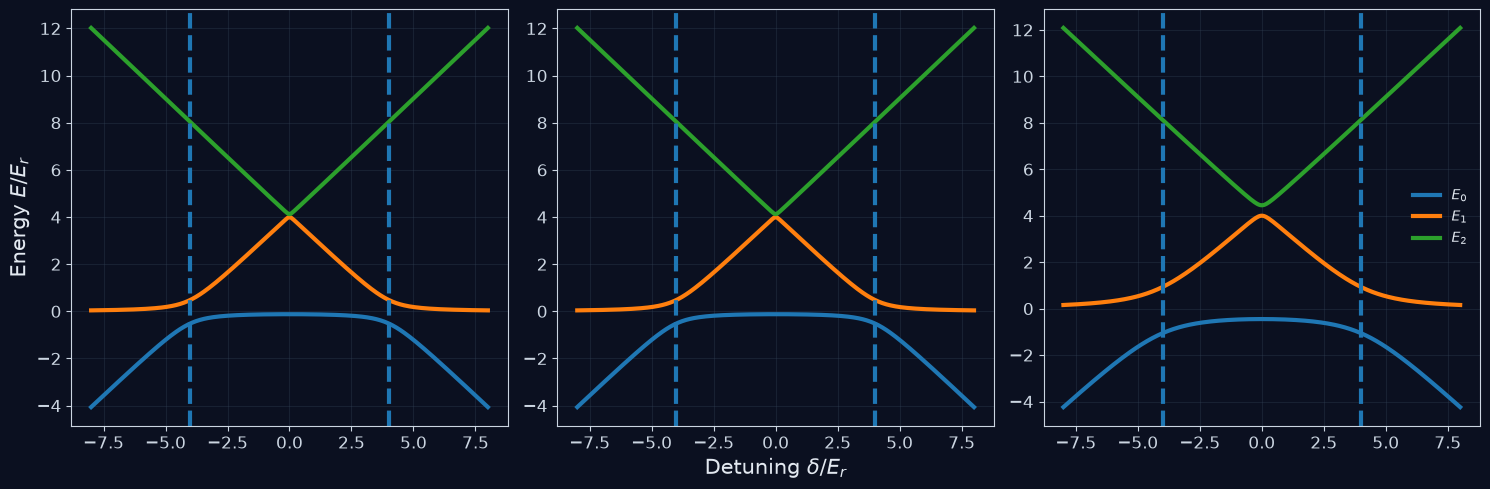

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for level in range(3):
    axes[0].plot(delta_values, all_energies[1][:, level], label=f"$E_{level}$")
    axes[1].plot(delta_values, all_energies[1][:, level], label=f"$E_{level}$")
    axes[2].plot(delta_values, all_energies[2][:, level], label=f"$E_{level}$")

for axis_idx in range(3):
    axes[axis_idx].axvline(-4, linestyle="--")
    axes[axis_idx].axvline(4, linestyle="--")

axes[1].set_xlabel(r"Detuning $\delta/E_r$")
axes[0].set_ylabel(r"Energy $E/E_r$")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
population_data = []

for delta in delta_values:
    H = bragg_hamiltonian(delta, omega=0.5)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    ground_state = eigenvectors[:, 0]
    population_data.append(np.abs(ground_state) ** 2)

population_data = np.array(population_data)

In [9]:
population_data = []

for delta in delta_values:
    H = bragg_hamiltonian(delta, omega=0.5)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    ground_state = eigenvectors[:, 0]
    population_data.append(np.abs(ground_state) ** 2)

population_data = np.array(population_data)

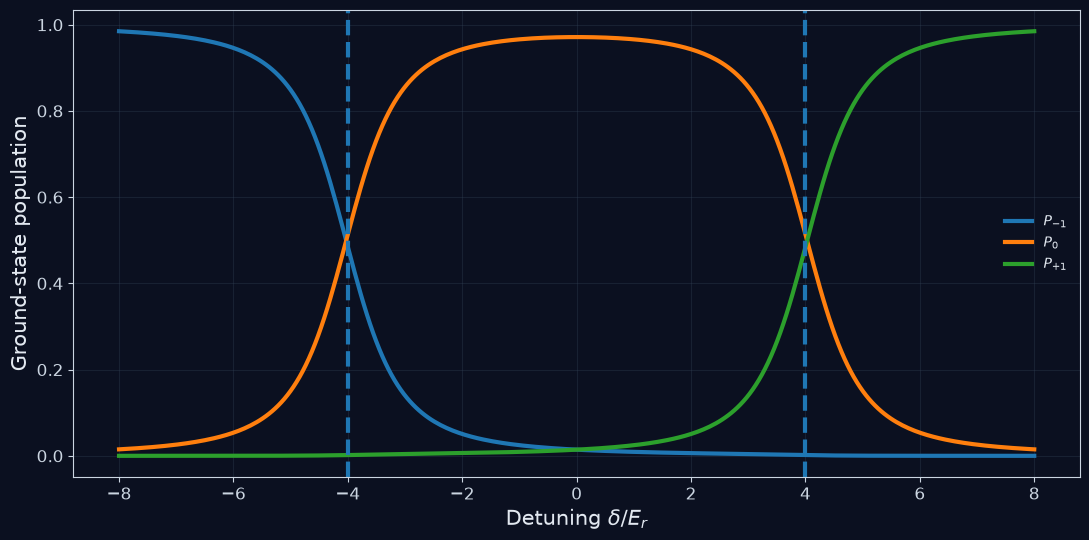

In [10]:
plt.plot(delta_values, population_data[:, 0], label=r"$P_{-1}$")
plt.plot(delta_values, population_data[:, 1], label=r"$P_0$")
plt.plot(delta_values, population_data[:, 2], label=r"$P_{+1}$")

plt.axvline(-4, linestyle="--")
plt.axvline(4, linestyle="--")
plt.xlabel(r"Detuning $\delta/E_r$")
plt.ylabel("Ground-state population")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
omega_values = [0.05, 0.1, 0.2, 0.5]

centre = 4.0
width = 1.0
points = 2001
deltas = np.linspace(centre - width, centre + width, points)
gaps = []
indexes = []

for omega in omega_values:
    gaps_for_this_omega = []
    for delta in deltas:
        energies = np.linalg.eigvalsh(bragg_hamiltonian(delta, omega))
        gaps_for_this_omega.append(energies[1] - energies[0])
    gaps.append(np.array(gaps_for_this_omega))

for i in range(4):
    gaps[i] = np.array(gaps[i])

min_gaps = []
for i in range(len(omega_values)):
    min_gaps.append(np.min(gaps[i]))

# Print table
print("\n" + "="*75)
print(f"{'Ω':^12} {'ΔE_min':^18} {'2Ω':^15} {'|ΔE_min - 2Ω|/(2Ω)':^25}")
print("="*75)

for i, omega in enumerate(omega_values):
    two_omega = 2 * omega
    relative_error = abs(min_gaps[i] - two_omega) / two_omega
    print(f"{omega:^12.4f} {min_gaps[i]:^18.8f} {two_omega:^15.4f} {relative_error:^25.8f}")

print("="*75)


     Ω             ΔE_min             2Ω           |ΔE_min - 2Ω|/(2Ω)    
   0.0500        0.09999854         0.1000             0.00001465        
   0.1000        0.19998454         0.2000             0.00007731        
   0.2000        0.39987529         0.4000             0.00031177        
   0.5000        0.99807493         1.0000             0.00192507        


In [12]:
def padded_bragg_hamiltonian(
    delta: float,
    omega: float,
    penalty: float = 13.0,
) -> np.ndarray:
    return np.array(
        [
            [4 + delta, omega, 0, 0],
            [omega, 0, omega, 0],
            [0, omega, 4 - delta, 0],
            [0, 0, 0, penalty],
        ],
        dtype=float,
    )

H3 = bragg_hamiltonian(delta=1.0, omega=0.5)
H4 = padded_bragg_hamiltonian(delta=1.0, omega=0.5)

e3 = np.linalg.eigvalsh(H3)
e4 = np.linalg.eigvalsh(H4)

print(e3)
print(e4[:3])

[-0.12865236  3.07793022  5.05072214]
[-0.12865236  3.07793022  5.05072214]


In [13]:
from itertools import product
from qiskit.quantum_info import Pauli, SparsePauliOp

def pauli_decompose(matrix: np.ndarray, tolerance: float = 1e-12):
    labels = []
    coefficients = []

    for symbols in product("IXYZ", repeat=2):
        label = "".join(symbols)
        pauli_matrix = Pauli(label).to_matrix()
        coefficient = np.trace(pauli_matrix @ matrix) / 4

        if abs(coefficient) > tolerance:
            labels.append(label)
            coefficients.append(np.real_if_close(coefficient))

    return SparsePauliOp(labels, coefficients)

In [14]:
def make_ansatz():
    theta = ParameterVector("theta", 4)

    circuit = QuantumCircuit(2)
    circuit.ry(theta[0], 0)
    circuit.ry(theta[1], 1)
    circuit.cx(0, 1)
    circuit.ry(theta[2], 0)
    circuit.ry(theta[3], 1)

    return circuit

In [15]:
deltas = [-8.0, 0.0, 8.0]
omega = 0.5
penalty = 13.0

for delta in deltas:
    print(f"\n--- delta = {delta} ---")

    # 1) Build Hamiltonians
    H3 = bragg_hamiltonian(delta=delta, omega=omega)
    H_matrix = padded_bragg_hamiltonian(
        delta=delta,
        omega=omega,
        penalty=penalty,
    )

    # 2) Pauli decomposition check
    H_pauli = pauli_decompose(H_matrix)
    print("Pauli decomposition correct:", np.allclose(H_pauli.to_matrix(), H_matrix))

    # 3) Ansatz / estimator / optimiser
    ansatz = make_ansatz()
    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=500)

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
    )

    # 4) VQE energy
    vqe_result = vqe.compute_minimum_eigenvalue(H_pauli)
    vqe_energy = np.real(vqe_result.eigenvalue)

    # 5) Exact ground energy from the physical 3x3 model
    eigenvalues_3d, eigenvectors_3d = np.linalg.eigh(H3)
    exact_energy = np.min(eigenvalues_3d)
    exact_state_3d = eigenvectors_3d[:, 0]

    # 6) Energy error
    energy_error = abs(vqe_energy - exact_energy)
    print("energy error:", energy_error)

    # 7) VQE statevector
    optimal_parameters = vqe_result.optimal_parameters
    optimal_circuit = ansatz.assign_parameters(optimal_parameters)
    vqe_state = Statevector.from_instruction(optimal_circuit).data

    # 8) Pad exact state to 4D for fidelity comparison
    exact_state_4d = np.array(
        [
            exact_state_3d[0],
            exact_state_3d[1],
            exact_state_3d[2],
            0.0,
        ],
        dtype=complex,
    )

    # 9) Fidelity and populations
    fidelity = abs(np.vdot(exact_state_4d, vqe_state)) ** 2
    vqe_populations = np.abs(vqe_state) ** 2

    print("fidelity:", fidelity)
    print("VQE populations:")
    print("  |00>:", vqe_populations[0])
    print("  |01>:", vqe_populations[1])
    print("  |10>:", vqe_populations[2])
    print("  |11>:", vqe_populations[3])


--- delta = -8.0 ---
Pauli decomposition correct: True


energy error: 8.936652040603121e-08
fidelity: 0.9999999938036113
VQE populations:
  |00>: 0.9849538295995331
  |01>: 0.015031436394324782
  |10>: 1.4729505809351903e-05
  |11>: 4.50033285599434e-09

--- delta = 0.0 ---
Pauli decomposition correct: True


energy error: 2.520876858647103e-08
fidelity: 0.9999999939911484
VQE populations:
  |00>: 0.014279448946713704
  |01>: 0.9714245297480197
  |10>: 0.014296021304491924
  |11>: 7.744225122221803e-13

--- delta = 8.0 ---
Pauli decomposition correct: True


energy error: 1.264826465785518e-08
fidelity: 0.9999999983419949
VQE populations:
  |00>: 1.4741910893645314e-05
  |01>: 0.015048305379838804
  |10>: 0.9849369526432136
  |11>: 6.605370538253737e-11


In [16]:
delta_values_vqe = np.linspace(-8, 8, 33)
omega = 0.5
penalty = 13.0
previous_optimal_parameters = None

results = {
    "delta": [],
    "exact_energy": [],
    "vqe_energy": [],
    "energy_error": [],
    "fidelity": [],
    "p_minus": [],
    "p_zero": [],
    "p_plus": [],
    "leakage": [],
}

for delta in delta_values_vqe:
    print(f"\n--- delta = {delta} ---")

    # 1) Build Hamiltonians
    H3 = bragg_hamiltonian(delta=delta, omega=omega)
    H_matrix = padded_bragg_hamiltonian(
        delta=delta,
        omega=omega,
        penalty=penalty,
    )

    # 2) Pauli decomposition check
    H_pauli = pauli_decompose(H_matrix)
    print("Pauli decomposition correct:", np.allclose(H_pauli.to_matrix(), H_matrix))

    # 3) Ansatz / estimator / optimiser
    ansatz = make_ansatz()
    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=500)

    if previous_optimal_parameters is None:
        initial_point = 2 * np.pi * np.random.random(ansatz.num_parameters)
    else:
        initial_point = np.asarray(previous_optimal_parameters, dtype=float)

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        initial_point=initial_point,
    )

    # 4) VQE energy
    vqe_result = vqe.compute_minimum_eigenvalue(H_pauli)
    vqe_energy = np.real(vqe_result.eigenvalue)
    previous_optimal_parameters = np.asarray(vqe_result.optimal_point, dtype=float)

    # 5) Exact ground energy from the physical 3x3 model
    eigenvalues_3d, eigenvectors_3d = np.linalg.eigh(H3)
    exact_energy = np.min(eigenvalues_3d)
    exact_state_3d = eigenvectors_3d[:, 0]

    # 6) Energy error
    energy_error = abs(vqe_energy - exact_energy)
    print("energy error:", energy_error)

    # 7) VQE statevector
    optimal_circuit = ansatz.assign_parameters(vqe_result.optimal_parameters)
    vqe_state = Statevector.from_instruction(optimal_circuit).data

    # 8) Pad exact state to 4D for fidelity comparison
    exact_state_4d = np.array(
        [
            exact_state_3d[0],
            exact_state_3d[1],
            exact_state_3d[2],
            0.0,
        ],
        dtype=complex,
    )

    # 9) Fidelity and populations
    fidelity = abs(np.vdot(exact_state_4d, vqe_state)) ** 2
    populations = np.abs(vqe_state) ** 2

    p_minus = populations[0]
    p_zero = populations[1]
    p_plus = populations[2]
    leakage = populations[3]

    # 10) Store results
    results["delta"].append(delta)
    results["exact_energy"].append(exact_energy)
    results["vqe_energy"].append(vqe_energy)
    results["energy_error"].append(energy_error)
    results["fidelity"].append(fidelity)
    results["p_minus"].append(p_minus)
    results["p_zero"].append(p_zero)
    results["p_plus"].append(p_plus)
    results["leakage"].append(leakage)

import os
os.makedirs("results", exist_ok=True)
dataframe = pd.DataFrame(results)
dataframe.to_csv("results/vqe_detuning_sweep.csv", index=False)


--- delta = -8.0 ---
Pauli decomposition correct: True


energy error: 2.630494400079897e-08

--- delta = -7.5 ---
Pauli decomposition correct: True


energy error: 7.908348020890799e-08

--- delta = -7.0 ---
Pauli decomposition correct: True


energy error: 1.252345978031144e-07

--- delta = -6.5 ---
Pauli decomposition correct: True


energy error: 2.322546377442336e-08

--- delta = -6.0 ---
Pauli decomposition correct: True


...

energy error: 1.9449859411935222e-07

--- delta = 5.5 ---
Pauli decomposition correct: True


energy error: 5.5808198506923645e-08

--- delta = 6.0 ---
Pauli decomposition correct: True


energy error: 3.4925457192969134e-08

--- delta = 6.5 ---
Pauli decomposition correct: True


energy error: 4.6726107960637364e-07

--- delta = 7.0 ---
Pauli decomposition correct: True
energy error: 1.6031470595478936e-07

--- delta = 7.5 ---
Pauli decomposition correct: True


energy error: 2.3638826407434976e-07

--- delta = 8.0 ---
Pauli decomposition correct: True
energy error: 3.78282791757556e-08


## Final Figures and Summary Tables

This section produces the four final figures, the energy/fidelity and optimizer comparison tables, the two-qubit ansatz circuit diagram, and the Pauli decomposition of the encoded Hamiltonian. The detuning-sweep figures are built directly from `results/vqe_detuning_sweep.csv`; the eigenspectrum and avoided-crossing figures reuse the exact-diagonalization arrays computed earlier in the notebook.

In [17]:
import os
import time

os.makedirs("figures", exist_ok=True)
sweep_df = pd.read_csv("results/vqe_detuning_sweep.csv")
sweep_df.head()

,delta,exact_energy,vqe_energy,energy_error,fidelity,p_minus,p_zero,p_plus,leakage
0,-8.0,-4.061786,-4.061786,2.630494e-08,1.0,0.984942,0.015044,0.000015,1.484502e-09
1,-7.5,-3.570348,-3.570348,7.908348e-08,1.0,0.980598,0.019381,0.000021,6.855979e-10
2,-7.0,-3.081597,-3.081597,1.252346e-07,1.0,0.973976,0.025991,0.000033,2.551452e-09
3,-6.5,-2.596979,-2.596979,2.322546e-08,1.0,0.963717,0.036230,0.000053,7.942765e-10
4,-6.0,-2.119132,-2.119132,2.361991e-08,1.0,0.946229,0.053680,0.000092,2.918260e-10


### Figure 1 — Exact eigenspectrum vs detuning $\delta$

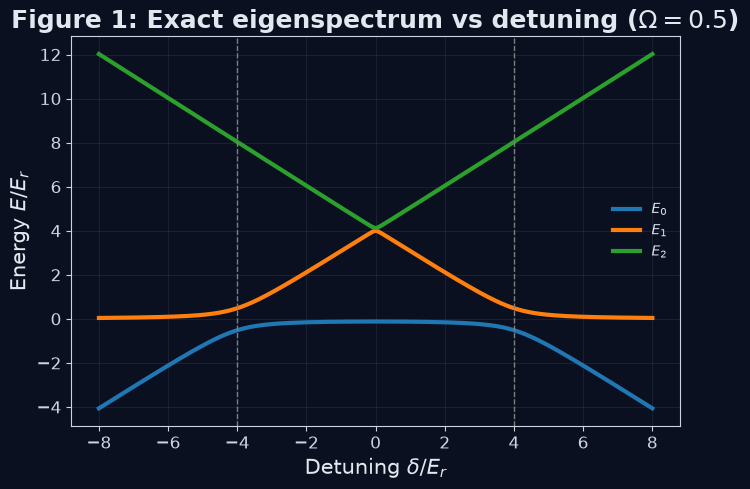

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
for level in range(3):
    ax.plot(delta_values, all_energies[1][:, level], label=f"$E_{level}$")

ax.axvline(-4, color="grey", linestyle="--", linewidth=1)
ax.axvline(4, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel(r"Detuning $\delta / E_r$")
ax.set_ylabel(r"Energy $E / E_r$")
ax.set_title(r"Figure 1: Exact eigenspectrum vs detuning ($\Omega = 0.5$)")
ax.legend()
fig.tight_layout()
fig.savefig("figures/fig1_exact_eigenspectrum.png", dpi=150)
plt.show()

### Figure 2 — Exact and VQE ground-state energies vs detuning $\delta$

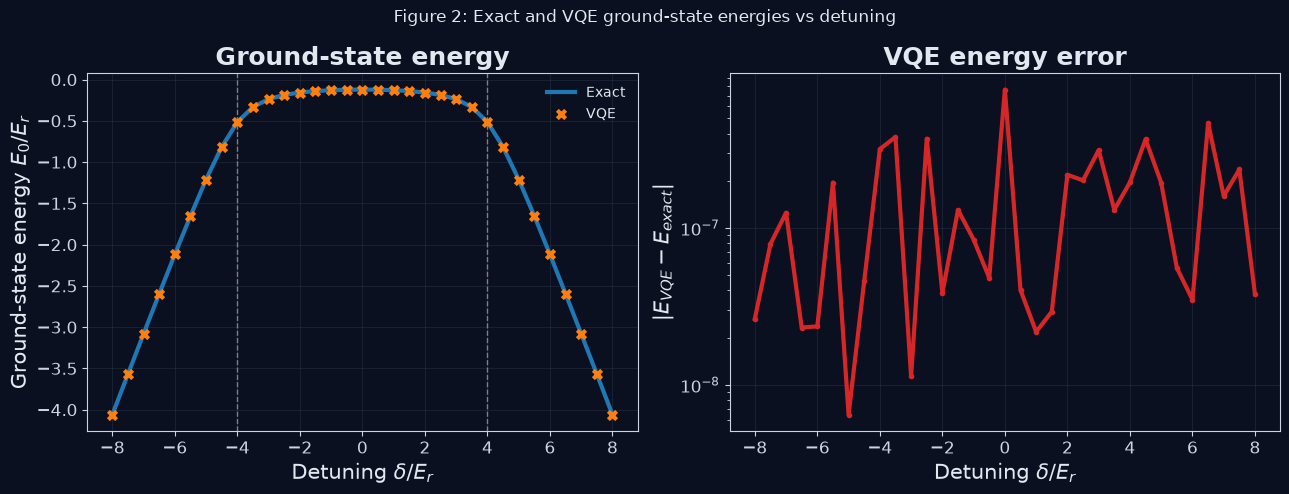

In [19]:
fig, (ax_energy, ax_error) = plt.subplots(1, 2, figsize=(13, 5))

ax_energy.plot(sweep_df["delta"], sweep_df["exact_energy"], label="Exact", color="tab:blue")
ax_energy.scatter(sweep_df["delta"], sweep_df["vqe_energy"], label="VQE", color="tab:orange", marker="x", zorder=3)
ax_energy.axvline(-4, color="grey", linestyle="--", linewidth=1)
ax_energy.axvline(4, color="grey", linestyle="--", linewidth=1)
ax_energy.set_xlabel(r"Detuning $\delta / E_r$")
ax_energy.set_ylabel(r"Ground-state energy $E_0 / E_r$")
ax_energy.set_title("Ground-state energy")
ax_energy.legend()

ax_error.semilogy(sweep_df["delta"], sweep_df["energy_error"], color="tab:red", marker="o", markersize=3)
ax_error.set_xlabel(r"Detuning $\delta / E_r$")
ax_error.set_ylabel(r"$|E_{VQE} - E_{exact}|$")
ax_error.set_title("VQE energy error")

fig.suptitle("Figure 2: Exact and VQE ground-state energies vs detuning")
fig.tight_layout()
fig.savefig("figures/fig2_exact_vqe_energy.png", dpi=150)
plt.show()

### Figure 3 — Exact and VQE momentum populations vs detuning $\delta$

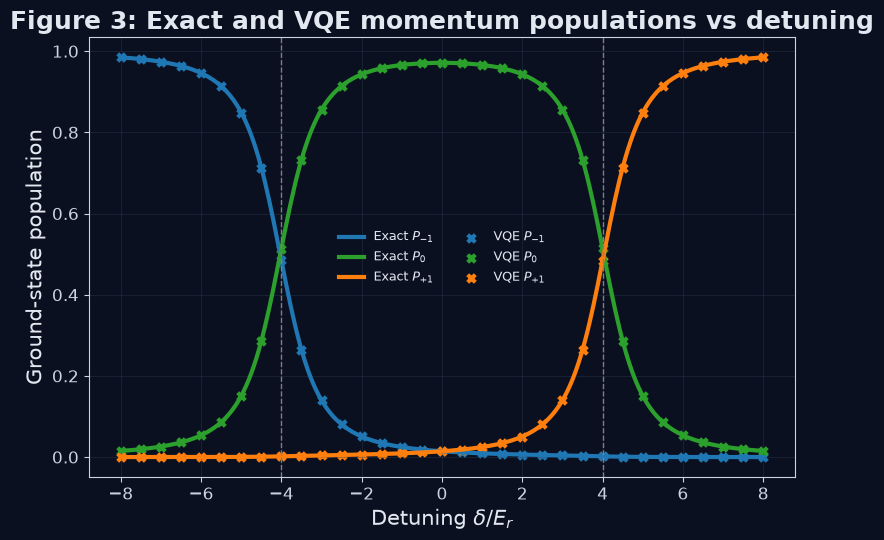

Max leakage into |11>: 3.919219948302471e-09


In [20]:
fig, ax = plt.subplots(figsize=(8, 5.5))

colors = {"minus": "tab:blue", "zero": "tab:green", "plus": "tab:orange"}

ax.plot(delta_values, population_data[:, 0], color=colors["minus"], label=r"Exact $P_{-1}$")
ax.plot(delta_values, population_data[:, 1], color=colors["zero"], label=r"Exact $P_0$")
ax.plot(delta_values, population_data[:, 2], color=colors["plus"], label=r"Exact $P_{+1}$")

ax.scatter(sweep_df["delta"], sweep_df["p_minus"], color=colors["minus"], marker="x", s=30, label=r"VQE $P_{-1}$")
ax.scatter(sweep_df["delta"], sweep_df["p_zero"], color=colors["zero"], marker="x", s=30, label=r"VQE $P_0$")
ax.scatter(sweep_df["delta"], sweep_df["p_plus"], color=colors["plus"], marker="x", s=30, label=r"VQE $P_{+1}$")

ax.axvline(-4, color="grey", linestyle="--", linewidth=1)
ax.axvline(4, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel(r"Detuning $\delta / E_r$")
ax.set_ylabel("Ground-state population")
ax.set_title("Figure 3: Exact and VQE momentum populations vs detuning")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig("figures/fig3_exact_vqe_populations.png", dpi=150)
plt.show()

print("Max leakage into |11>:", sweep_df["leakage"].max())

### Figure 4 — Minimum avoided-crossing gap vs $\Omega$

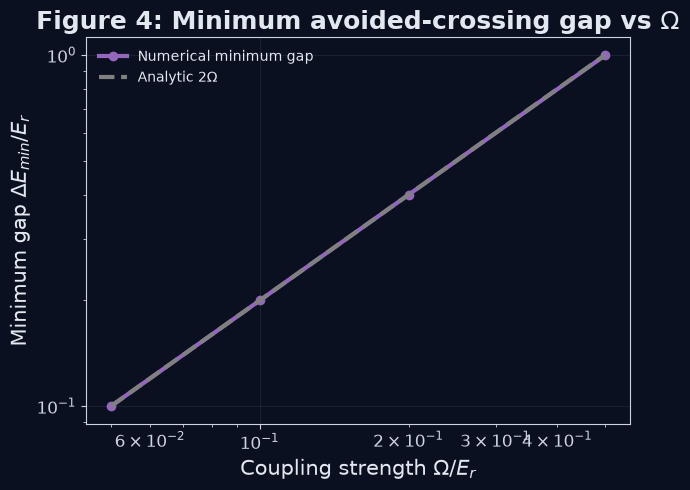

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 5))

ax.loglog(omega_values, min_gaps, "o-", color="tab:purple", label="Numerical minimum gap")
ax.loglog(omega_values, [2 * o for o in omega_values], "--", color="grey", label=r"Analytic $2\Omega$")

ax.set_xlabel(r"Coupling strength $\Omega / E_r$")
ax.set_ylabel(r"Minimum gap $\Delta E_{min} / E_r$")
ax.set_title(r"Figure 4: Minimum avoided-crossing gap vs $\Omega$")
ax.legend()
fig.tight_layout()
fig.savefig("figures/fig4_min_gap_vs_omega.png", dpi=150)
plt.show()

### Energy / fidelity comparison table

In [22]:
sample_deltas = [-8.0, -4.0, -2.0, 0.0, 2.0, 4.0, 8.0]
comparison_table = sweep_df[sweep_df["delta"].isin(sample_deltas)][
    ["delta", "exact_energy", "vqe_energy", "energy_error", "fidelity"]
].reset_index(drop=True)
comparison_table

,delta,exact_energy,vqe_energy,energy_error,fidelity
0,-8.0,-4.061786,-4.061786,2.630494e-08,1.0
1,-4.0,-0.514896,-0.514895,3.184852e-07,1.0
2,-2.0,-0.156534,-0.156534,3.858524e-08,1.0
3,0.0,-0.121320,-0.121320,7.635271e-07,1.0
4,2.0,-0.156534,-0.156534,2.185789e-07,1.0
5,4.0,-0.514896,-0.514895,1.956497e-07,1.0
6,8.0,-4.061786,-4.061786,3.782828e-08,1.0


### Optimizer comparison table

In [23]:
from qiskit_algorithms.optimizers import SPSA, NELDER_MEAD, L_BFGS_B

delta_bench = 4.0
omega_bench = 0.5
penalty_bench = 13.0

H_bench = pauli_decompose(padded_bragg_hamiltonian(delta_bench, omega_bench, penalty_bench))
H3_bench = bragg_hamiltonian(delta_bench, omega_bench)
exact_bench_eigenvalues, exact_bench_eigenvectors = np.linalg.eigh(H3_bench)
exact_bench_energy = exact_bench_eigenvalues[0]
exact_bench_state_4d = np.array([*exact_bench_eigenvectors[:, 0], 0.0], dtype=complex)

rng = np.random.default_rng(42)
shared_initial_point = 2 * np.pi * rng.random(4)

optimizer_configs = {
    "COBYLA": COBYLA(maxiter=500),
    "Nelder-Mead": NELDER_MEAD(maxiter=500),
    "L-BFGS-B": L_BFGS_B(maxiter=500),
    "SPSA": SPSA(maxiter=200),
}

optimizer_rows = []
for name, optimizer in optimizer_configs.items():
    ansatz = make_ansatz()
    estimator = StatevectorEstimator()
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        initial_point=shared_initial_point.copy(),
    )

    start = time.perf_counter()
    result = vqe.compute_minimum_eigenvalue(H_bench)
    elapsed = time.perf_counter() - start

    vqe_energy = np.real(result.eigenvalue)
    optimal_circuit = ansatz.assign_parameters(result.optimal_parameters)
    vqe_state = Statevector.from_instruction(optimal_circuit).data
    fidelity = abs(np.vdot(exact_bench_state_4d, vqe_state)) ** 2

    optimizer_rows.append({
        "optimizer": name,
        "final_energy": vqe_energy,
        "energy_error": abs(vqe_energy - exact_bench_energy),
        "fidelity": fidelity,
        "function_evals": result.cost_function_evals,
        "time_s": elapsed,
    })

optimizer_table = pd.DataFrame(optimizer_rows)
optimizer_table

C:\Users\aarya\PycharmProjects\Qiskit\.venv\Lib\site-packages\qiskit_algorithms\optimizers\scipy_optimizer.py:162: OptimizeWarning: Unknown solver options: iprint
  raw_result = minimize(


,optimizer,final_energy,energy_error,fidelity,function_evals,time_s
0,COBYLA,-0.514895,3.530982e-07,1.000000,170,0.339359
1,Nelder-Mead,-0.514896,6.169804e-10,1.000000,164,0.190061
2,L-BFGS-B,-0.514896,1.251221e-13,1.000000,60,0.070890
3,SPSA,0.017942,5.328375e-01,0.467014,400,0.387651


### Two-qubit ansatz circuit diagram

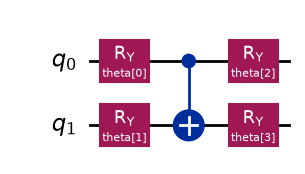

In [24]:
ansatz_diagram = make_ansatz()
fig_ansatz = ansatz_diagram.draw("mpl")
fig_ansatz.savefig("figures/ansatz_circuit.png", dpi=150, bbox_inches="tight")
fig_ansatz

### Pauli decomposition of the encoded Hamiltonian

In [25]:
delta_pauli = 0.0
omega_pauli = 0.5
penalty_pauli = 13.0

H_matrix_pauli = padded_bragg_hamiltonian(delta_pauli, omega_pauli, penalty_pauli)
H_pauli_op = pauli_decompose(H_matrix_pauli)

pauli_table = pd.DataFrame({
    "Pauli string": H_pauli_op.paulis.to_labels(),
    "coefficient": H_pauli_op.coeffs.real,
}).sort_values("Pauli string").reset_index(drop=True)

print(f"delta={delta_pauli}, Omega={omega_pauli}, penalty={penalty_pauli}")
print("Matches padded Hamiltonian exactly:", np.allclose(H_pauli_op.to_matrix(), H_matrix_pauli))
pauli_table

delta=0.0, Omega=0.5, penalty=13.0
Matches padded Hamiltonian exactly: True


,Pauli string,coefficient
0,II,5.25
1,IX,0.25
2,IZ,-1.25
3,XX,0.25
4,YY,0.25
5,ZI,-3.25
6,ZX,0.25
7,ZZ,3.25


### Figure 5 — VQE ground-state momentum-space probability density at $\delta = -4, 0, 4$

<>:41: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\h'
C:\Users\aarya\AppData\Local\Temp\ipykernel_14140\782478996.py:41: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel("Momentum order $n$ (units of $2\hbar k_L$)")


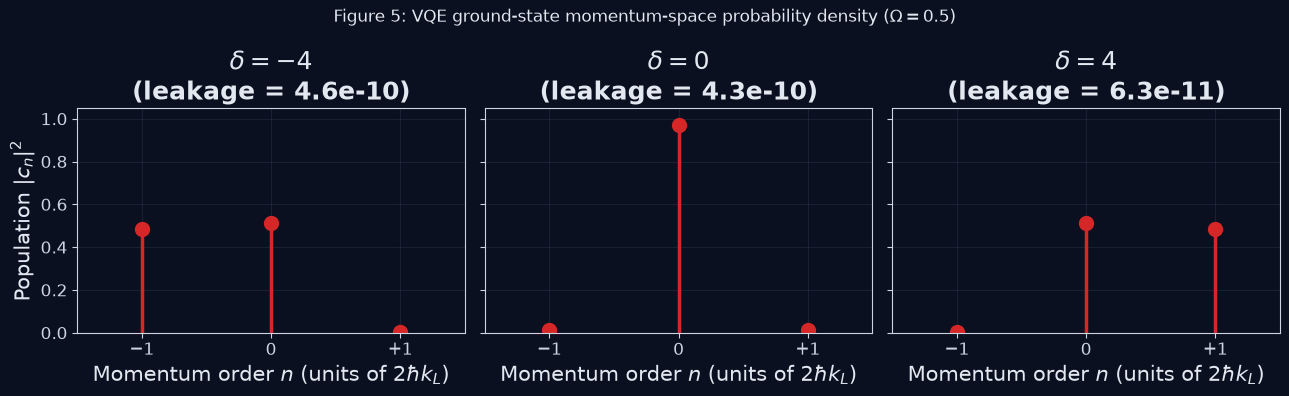

In [26]:
wavefunction_deltas = [-4.0, 0.0, 4.0]
omega_wf = 0.5
penalty_wf = 13.0
momentum_orders = np.array([-1, 0, 1])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
rng_wf = np.random.default_rng(0)

for ax, delta_wf in zip(axes, wavefunction_deltas):
    H_matrix_wf = padded_bragg_hamiltonian(delta_wf, omega_wf, penalty_wf)
    H_pauli_wf = pauli_decompose(H_matrix_wf)

    ansatz_wf = make_ansatz()
    estimator_wf = StatevectorEstimator()
    optimizer_wf = COBYLA(maxiter=500)
    initial_point_wf = 2 * np.pi * rng_wf.random(ansatz_wf.num_parameters)

    vqe_wf = VQE(
        estimator=estimator_wf,
        ansatz=ansatz_wf,
        optimizer=optimizer_wf,
        initial_point=initial_point_wf,
    )
    result_wf = vqe_wf.compute_minimum_eigenvalue(H_pauli_wf)

    optimal_circuit_wf = ansatz_wf.assign_parameters(result_wf.optimal_parameters)
    vqe_state_wf = Statevector.from_instruction(optimal_circuit_wf).data
    populations_wf = np.abs(vqe_state_wf) ** 2  # |00>, |01>, |10>, |11>(leakage)

    markerline, stemlines, baseline = ax.stem(
        momentum_orders, populations_wf[:3], basefmt=" "
    )
    plt.setp(markerline, markersize=10, color="tab:red")
    plt.setp(stemlines, linewidth=2.5, color="tab:red")

    ax.set_xticks(momentum_orders)
    ax.set_xticklabels([r"$-1$", r"$0$", r"$+1$"])
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(rf"$\delta = {delta_wf:g}$" + f"\n(leakage = {populations_wf[3]:.1e})")
    ax.set_xlabel("Momentum order $n$ (units of $2\hbar k_L$)")

axes[0].set_ylabel(r"Population $|c_n|^2$")
fig.suptitle(
    r"Figure 5: VQE ground-state momentum-space probability density ($\Omega = 0.5$)"
)
fig.tight_layout()
fig.savefig("figures/fig5_momentum_wavefunctions.png", dpi=150)
plt.show()